In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Optional
import gym
from gym import spaces

In [2]:
# Configuración del entorno
@dataclass
class RobotArmConfig:
    """Configuración del brazo robótico"""
    num_joints: int = 3  # Número de articulaciones
    workspace_size: float = 1.0  # Espacio de trabajo en metros
    max_steps: int = 50  # Pasos máximos por episodio
    cup_radius: float = 0.05  # Radio del vaso en metros
    success_threshold: float = 0.1  # Distancia para considerar éxito

In [3]:
class RobotArmEnv(gym.Env):
    """Entorno del brazo robótico para manipulación de objetos"""
    
    def __init__(self, config: RobotArmConfig):
        super().__init__()
        self.config = config
        
        # Espacios de acción y observación
        self.action_space = spaces.Box(
            low=-1.0, high=1.0, 
            shape=(config.num_joints,), dtype=np.float32
        )
        
        # Estado: posición del vaso (x,y), ángulos de articulaciones, posición del efector
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(2 + config.num_joints + 2,), dtype=np.float32
        )
        
        self.reset()
        
    def reset(self):
        """Reinicia el entorno"""
        # Posición aleatoria del vaso en el eje X
        self.cup_position = np.array([
            np.random.uniform(-self.config.workspace_size/2, self.config.workspace_size/2),
            0.0  # En el plano del suelo
        ])
        
        # Ángulos iniciales de las articulaciones
        self.joint_angles = np.zeros(self.config.num_joints)
        
        # Calcular posición del efector final
        self.end_effector_pos = self._forward_kinematics(self.joint_angles)
        
        self.steps = 0
        self.episode_reward = 0
        
        return self._get_observation()
    
    def _forward_kinematics(self, angles):
        """Calcula la posición del efector final"""
        # Simplificación: brazo planar con longitudes iguales
        link_length = self.config.workspace_size / self.config.num_joints
        x, y = 0, 0
        cumulative_angle = 0
        
        for i, angle in enumerate(angles):
            cumulative_angle += angle
            x += link_length * np.cos(cumulative_angle)
            y += link_length * np.sin(cumulative_angle)
            
        return np.array([x, y])
    
    def _get_observation(self):
        """Obtiene el estado actual del sistema"""
        return np.concatenate([
            self.cup_position,
            self.joint_angles,
            self.end_effector_pos
        ])
    
    def step(self, action):
        """Ejecuta una acción en el entorno"""
        # Aplicar acción (cambios en ángulos de articulaciones)
        self.joint_angles += action * 0.1  # Factor de escala
        self.joint_angles = np.clip(self.joint_angles, -np.pi, np.pi)
        
        # Actualizar posición del efector
        self.end_effector_pos = self._forward_kinematics(self.joint_angles)
        
        # Calcular recompensa
        distance = np.linalg.norm(self.end_effector_pos - self.cup_position)
        
        # Recompensa basada en distancia
        reward = -distance
        
        # Bonus por golpear el vaso
        if distance < self.config.cup_radius:
            reward += 10.0
            done = True
        else:
            done = False
            
        if distance < self.config.cup_radius * 2:
            reward += 1.0
            
        self.steps += 1
        if self.steps >= self.config.max_steps:
            done = True
            reward -= 5.0  # Penalización por timeout
            
        self.episode_reward += reward
        
        return self._get_observation(), reward, done, {}

In [4]:
# Red neuronal para la política
class PolicyNetwork(nn.Module):
    """Red neuronal para la política del agente"""
    
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.log_std = nn.Parameter(torch.zeros(output_size))
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        mean = torch.tanh(self.fc3(x))
        std = torch.exp(self.log_std)
        return mean, std

### 🧠 PPO 

La clase `PPOAgent` utiliza la siguiente función de pérdida basada en el algoritmo **Proximal Policy Optimization (PPO)**:

$$
L^{PPO}(\theta) = \mathbb{E}_t \left[ \min \left( r_t(\theta) \cdot \hat{A}_t,\ \text{clip}(r_t(\theta), 1 - \epsilon, 1 + \epsilon) \cdot \hat{A}_t \right) \right]
$$

donde:

- $r_t(\theta) = \frac{\pi_\theta(a_t \mid s_t)}{\pi_{\theta_{\text{old}}}(a_t \mid s_t)} = \exp(\log \pi_\theta - \log \pi_{\theta_{\text{old}}})$ es el **ratio** entre la nueva y la antigua política.
- $\hat{A}_t$ es una estimación de la ventaja o retorno normalizado.
- $\epsilon$ es el valor de clipping (en este caso $\epsilon = 0.2$).

La pérdida final que se minimiza en el código es:

$$
\mathcal{L} = - \mathbb{E}_t \left[ \min(surr1, surr2) \right]
$$

donde:

- $\text{surr1} = r_t \cdot \hat{A}_t$
- $\text{surr2} = \text{clip}(r_t, 1 - \epsilon, 1 + \epsilon) \cdot \hat{A}_t$


In [ ]:
# Agente PPO
class PPOAgent:
    """Agente que usa Proximal Policy Optimization"""
    
    def __init__(self, state_dim, action_dim, lr=3e-4):
        self.policy = PolicyNetwork(state_dim, 128, action_dim)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        self.gamma = 0.99
        self.eps_clip = 0.2
        self.k_epochs = 4
        
        # Buffer para almacenar experiencias
        self.states = []
        self.actions = []
        self.rewards = []
        self.log_probs = []
        self.values = []
        self.dones = []
        
    def get_action(self, state):
        """Obtiene una acción basada en la política actual"""
        state = torch.FloatTensor(state)
        mean, std = self.policy(state)
        dist = torch.distributions.Normal(mean, std)
        action = dist.sample()
        log_prob = dist.log_prob(action).sum()
        
        return action.numpy(), log_prob
    
    def store_transition(self, state, action, reward, log_prob, done):
        """Almacena una transición en el buffer"""
        self.states.append(state)
        self.actions.append(action)
        self.rewards.append(reward)
        self.log_probs.append(log_prob)
        self.dones.append(done)
        
    def train(self):
        """Entrena la política usando PPO"""
        # Calcular retornos descontados
        returns = []
        discounted_reward = 0
        for reward, done in zip(reversed(self.rewards), reversed(self.dones)):
            if done:
                discounted_reward = 0
            discounted_reward = reward + self.gamma * discounted_reward
            returns.insert(0, discounted_reward)
            
        # Normalizar retornos
        returns = torch.tensor(returns, dtype=torch.float32)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        
        # Convertir a tensores
        states = torch.tensor(np.array(self.states), dtype=torch.float32)
        actions = torch.tensor(np.array(self.actions), dtype=torch.float32)
        old_log_probs = torch.tensor(self.log_probs, dtype=torch.float32)
        
        # Actualización PPO
        for _ in range(self.k_epochs):
            # Evaluar acciones actuales
            mean, std = self.policy(states)
            dist = torch.distributions.Normal(mean, std)
            new_log_probs = dist.log_prob(actions).sum(dim=1)
            
            # Ratio de probabilidades
            ratio = torch.exp(new_log_probs - old_log_probs)
            
            # Pérdida PPO
            surr1 = ratio * returns
            surr2 = torch.clamp(ratio, 1 - self.eps_clip, 1 + self.eps_clip) * returns
            loss = -torch.min(surr1, surr2).mean()
            
            # Actualizar política
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
        # Limpiar buffer
        self.states.clear()
        self.actions.clear()
        self.rewards.clear()
        self.log_probs.clear()
        self.dones.clear()

In [6]:
# Sistema de Curriculum Learning
class CurriculumManager:
    """Gestiona el curriculum learning para el entrenamiento"""
    
    def __init__(self, initial_difficulty=0.2, max_difficulty=1.0):
        self.current_difficulty = initial_difficulty
        self.max_difficulty = max_difficulty
        self.success_rate_history = deque(maxlen=100)
        self.difficulty_history = []
        self.phase = "initial"  # initial, intermediate, final
        
    def update_difficulty(self, success_rate):
        """Actualiza la dificultad basada en el rendimiento"""
        self.success_rate_history.append(success_rate)
        
        if len(self.success_rate_history) >= 20:
            avg_success = np.mean(list(self.success_rate_history)[-20:])
            
            # Sistema de fases para curriculum más robusto
            if self.phase == "initial" and avg_success > 0.7:
                self.phase = "intermediate"
                self.current_difficulty = 0.5
            elif self.phase == "intermediate" and avg_success > 0.7:
                self.phase = "final"
                self.current_difficulty = 0.8
            elif self.phase == "final" and avg_success > 0.7:
                # Aumentar gradualmente hasta dificultad máxima
                self.current_difficulty = min(
                    self.current_difficulty * 1.05, 
                    self.max_difficulty
                )
            
            # Ajustes finos dentro de cada fase
            elif avg_success > 0.8:
                self.current_difficulty = min(
                    self.current_difficulty * 1.1, 
                    self.max_difficulty
                )
            elif avg_success < 0.5:
                self.current_difficulty = max(
                    self.current_difficulty * 0.9, 
                    0.1
                )
                
        self.difficulty_history.append(self.current_difficulty)
        
    def get_task_params(self):
        """Obtiene parámetros de la tarea según la dificultad actual"""
        # La dificultad afecta el rango de posiciones del vaso
        workspace_range = self.current_difficulty
        return {
            'workspace_range': workspace_range,
            'max_steps': int(50 + (1 - self.current_difficulty) * 50)
        }

### Fórmula de MSELoss (Mean Squared Error)

$$
\mathcal{L}_{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

**Donde:**

- $\mathcal{L}_{MSE}$: pérdida de error cuadrático medio  
- $n$: número total de muestras  
- $y_i$: valor real (target) de la muestra $i$  
- $\hat{y}_i$: valor predicho por el modelo para la muestra $i$  
- $(y_i - \hat{y}_i)^2$: error cuadrático de la muestra $i$


In [7]:
# Aprendizaje por Imitación
class ImitationLearning:
    """Sistema de aprendizaje por imitación"""
    
    def __init__(self, agent):
        self.agent = agent
        self.demonstrations = []
        
    def generate_expert_demonstration(self, env, num_demos=100):
        """Genera demostraciones expertas usando un controlador simple"""
        demos = []
        
        for _ in range(num_demos):
            state = env.reset()
            trajectory = []
            
            for _ in range(env.config.max_steps):
                # Controlador experto simple: mover hacia el vaso
                cup_pos = state[:2]
                ee_pos = state[-2:]
                
                # Calcular acción óptima (simplificada)
                direction = cup_pos - ee_pos
                action = np.clip(direction * 2, -1, 1)
                
                # Añadir ruido pequeño para variabilidad
                action += np.random.normal(0, 0.1, size=action.shape)
                action = np.clip(action, -1, 1)
                
                # Extender acción para todas las articulaciones
                full_action = np.zeros(env.config.num_joints)
                full_action[:2] = action
                
                next_state, reward, done, _ = env.step(full_action)
                trajectory.append((state, full_action, reward))
                
                state = next_state
                if done:
                    break
                    
            demos.append(trajectory)
            
        self.demonstrations = demos
        return demos
    
    def pretrain_with_behavior_cloning(self, epochs=50):
        """Pre-entrena el agente usando behavior cloning"""
        print("Pre-entrenando con behavior cloning...")
        
        # Preparar datos
        states = []
        actions = []
        
        for demo in self.demonstrations:
            for state, action, _ in demo:
                states.append(state)
                actions.append(action)
                
        states = torch.tensor(states, dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.float32)
        
        # Entrenar
        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.agent.policy.parameters(), lr=1e-3)
        
        for epoch in range(epochs):
            # Mini-batch training
            indices = torch.randperm(len(states))
            batch_size = 32
            
            total_loss = 0
            for i in range(0, len(indices), batch_size):
                batch_indices = indices[i:i+batch_size]
                batch_states = states[batch_indices]
                batch_actions = actions[batch_indices]
                
                # Predecir acciones
                mean, _ = self.agent.policy(batch_states)
                
                # Calcular pérdida
                loss = criterion(mean, batch_actions)
                
                # Actualizar
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                total_loss += loss.item()
                
            if epoch % 10 == 0:
                print(f"Epoch {epoch}, Loss: {total_loss/len(states)*batch_size:.4f}")

In [8]:
# Sistema principal de entrenamiento
class RobotArmTrainer:
    """Sistema completo de entrenamiento con curriculum learning"""
    
    def __init__(self):
        self.config = RobotArmConfig()
        self.env = RobotArmEnv(self.config)
        self.agent = PPOAgent(
            state_dim=self.env.observation_space.shape[0],
            action_dim=self.env.action_space.shape[0]
        )
        self.curriculum = CurriculumManager()
        self.imitation = ImitationLearning(self.agent)
        
        # Métricas
        self.episode_rewards = []
        self.success_rates = []
        self.first_attempt_successes = []
        
    def train(self, num_episodes=1000, use_imitation=True, use_curriculum=True):
        """Entrena el agente con todas las técnicas"""
        
        # Fase 1: Aprendizaje por imitación
        if use_imitation:
            print("=== Fase 1: Aprendizaje por Imitación ===")
            self.imitation.generate_expert_demonstration(self.env, num_demos=200)
            self.imitation.pretrain_with_behavior_cloning(epochs=100)
            
        # Fase 2: Entrenamiento con RL y Curriculum Learning
        print("\n=== Fase 2: Entrenamiento con PPO y Curriculum Learning ===")
        
        for episode in range(num_episodes):
            # Ajustar dificultad si se usa curriculum
            if use_curriculum:
                task_params = self.curriculum.get_task_params()
                self.env.config.workspace_size = task_params['workspace_range']
                self.env.config.max_steps = task_params['max_steps']
            
            state = self.env.reset()
            episode_reward = 0
            first_attempt = True
            success = False
            
            while True:
                # Obtener acción
                action, log_prob = self.agent.get_action(state)
                
                # Ejecutar acción
                next_state, reward, done, _ = self.env.step(action)
                
                # Almacenar transición
                self.agent.store_transition(state, action, reward, log_prob, done)
                
                episode_reward += reward
                state = next_state
                
                # Verificar éxito en el primer intento
                if first_attempt and reward > 5:  # Umbral de éxito
                    self.first_attempt_successes.append(1)
                    success = True
                elif first_attempt and done:
                    self.first_attempt_successes.append(0)
                    first_attempt = False
                
                if done:
                    if reward > 5:
                        success = True
                    break
            
            # Actualizar métricas
            self.episode_rewards.append(episode_reward)
            
            # Entrenar cada 20 episodios
            if (episode + 1) % 20 == 0:
                self.agent.train()
                
                # Calcular tasa de éxito
                recent_successes = self.first_attempt_successes[-100:]
                success_rate = np.mean(recent_successes) if recent_successes else 0
                self.success_rates.append(success_rate)
                
                # Actualizar curriculum
                if use_curriculum:
                    self.curriculum.update_difficulty(success_rate)
                
                print(f"Episode {episode+1}, Avg Reward: {np.mean(self.episode_rewards[-20:]):.2f}, "
                      f"Success Rate: {success_rate*100:.1f}%, "
                      f"Difficulty: {self.curriculum.current_difficulty:.2f}")
                
                # Verificar si alcanzamos el objetivo
                if success_rate >= 0.7 and self.curriculum.current_difficulty >= 0.8:
                    print(f"\n¡Objetivo alcanzado! Tasa de éxito del {success_rate*100:.1f}% "
                          f"en los primeros intentos después de {episode+1} episodios.")
                    print(f"Dificultad actual: {self.curriculum.current_difficulty:.2f}")
                    
                    # Continuar entrenando hasta dificultad máxima
                    if self.curriculum.current_difficulty >= 0.95:
                        break
        
        return self.success_rates
    
    def evaluate(self, num_episodes=100):
        """Evalúa el rendimiento del agente entrenado"""
        print("\n=== Evaluación Final ===")
        successes = []
        
        # Restaurar configuración completa
        self.env.config.workspace_size = 1.0
        
        for _ in range(num_episodes):
            state = self.env.reset()
            done = False
            steps = 0
            
            while not done and steps < self.config.max_steps:
                action, _ = self.agent.get_action(state)
                state, reward, done, _ = self.env.step(action)
                steps += 1
                
                if reward > 5:  # Éxito
                    successes.append(1)
                    break
            else:
                successes.append(0)
                
        success_rate = np.mean(successes)
        print(f"Tasa de éxito final: {success_rate*100:.1f}%")
        
        return success_rate
    
    def plot_results(self):
        """Visualiza los resultados del entrenamiento"""
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))
        
        # Recompensas por episodio
        ax1.plot(self.episode_rewards)
        ax1.set_xlabel('Episodio')
        ax1.set_ylabel('Recompensa')
        ax1.set_title('Recompensa por Episodio')
        ax1.grid(True)
        
        # Tasa de éxito
        ax2.plot([i*20 for i in range(len(self.success_rates))], 
                 [s*100 for s in self.success_rates])
        ax2.axhline(y=70, color='r', linestyle='--', label='Objetivo (70%)')
        ax2.set_xlabel('Episodio')
        ax2.set_ylabel('Tasa de Éxito (%)')
        ax2.set_title('Tasa de Éxito en Primeros Intentos')
        ax2.legend()
        ax2.grid(True)
        
        # Progresión de dificultad
        ax3.plot([i*20 for i in range(len(self.curriculum.difficulty_history))], 
                 self.curriculum.difficulty_history)
        ax3.set_xlabel('Episodio')
        ax3.set_ylabel('Nivel de Dificultad')
        ax3.set_title('Progresión del Curriculum Learning')
        ax3.grid(True)
        
        plt.tight_layout()
        plt.savefig('robot_arm_training_results.png')
        plt.show()

Iniciando entrenamiento del brazo robótico...
=== Fase 1: Aprendizaje por Imitación ===
Pre-entrenando con behavior cloning...
Epoch 0, Loss: 0.0269
Epoch 10, Loss: 0.0050
Epoch 20, Loss: 0.0049
Epoch 30, Loss: 0.0048
Epoch 40, Loss: 0.0048
Epoch 50, Loss: 0.0048
Epoch 60, Loss: 0.0048
Epoch 70, Loss: 0.0047
Epoch 80, Loss: 0.0047
Epoch 90, Loss: 0.0047

=== Fase 2: Entrenamiento con PPO y Curriculum Learning ===
Episode 20, Avg Reward: 8.71, Success Rate: 35.0%, Difficulty: 0.20
Episode 40, Avg Reward: 10.05, Success Rate: 37.5%, Difficulty: 0.20
Episode 60, Avg Reward: 6.23, Success Rate: 36.7%, Difficulty: 0.20
Episode 80, Avg Reward: 13.26, Success Rate: 33.8%, Difficulty: 0.20
Episode 100, Avg Reward: 10.43, Success Rate: 38.0%, Difficulty: 0.20
Episode 120, Avg Reward: 9.51, Success Rate: 39.0%, Difficulty: 0.20
Episode 140, Avg Reward: 12.96, Success Rate: 39.0%, Difficulty: 0.20
Episode 160, Avg Reward: 2.56, Success Rate: 41.0%, Difficulty: 0.20
Episode 180, Avg Reward: 17.12,

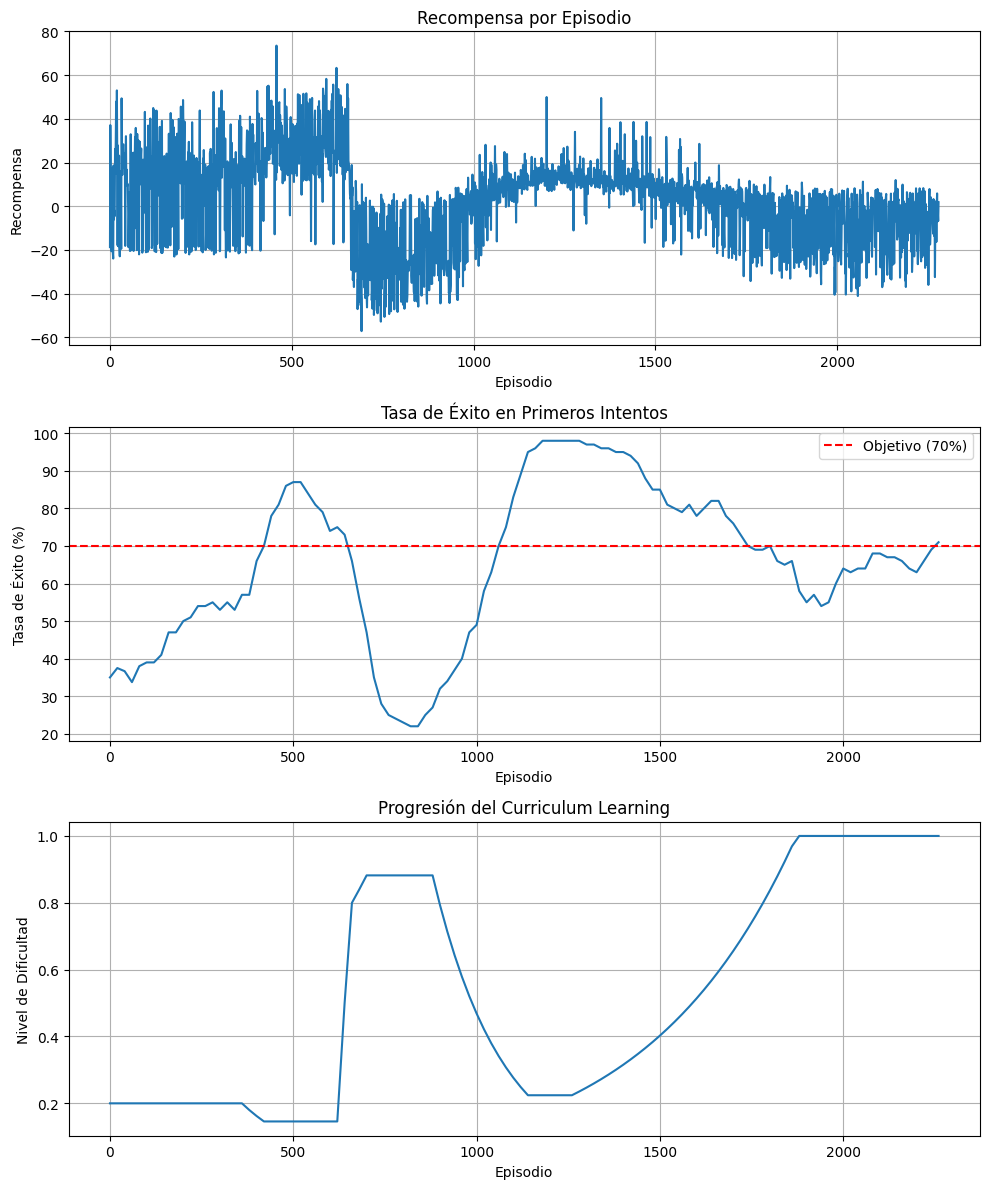


=== Resumen Final ===
Tasa de éxito en evaluación: 69.0%
Objetivo alcanzado: No

=== Evaluando en PyBullet ===
✅ Episodio 1: Éxito! (paso 8)
❌ Episodio 2: Fallo
✅ Episodio 3: Éxito! (paso 39)
✅ Episodio 4: Éxito! (paso 24)
✅ Episodio 5: Éxito! (paso 13)
✅ Episodio 6: Éxito! (paso 38)
✅ Episodio 7: Éxito! (paso 5)
✅ Episodio 8: Éxito! (paso 38)
❌ Episodio 9: Fallo
❌ Episodio 10: Fallo

📊 Tasa de éxito en PyBullet: 70.0%


In [ ]:
# Función principal
def main():
    """Ejecuta el entrenamiento completo"""
    print("Iniciando entrenamiento del brazo robótico...")
    
    # Crear entrenador
    trainer = RobotArmTrainer()
    
    # Entrenar con todas las técnicas
    success_rates = trainer.train(
        num_episodes=4000,
        use_imitation=True,
        use_curriculum=True
    )
    
    # Evaluar rendimiento final
    final_success_rate = trainer.evaluate(num_episodes=200)
    
    # Visualizar resultados
    trainer.plot_results()
    
    print(f"\n=== Resumen Final ===")
    print(f"Tasa de éxito en evaluación: {final_success_rate*100:.1f}%")
    print(f"Objetivo alcanzado: {'Sí' if final_success_rate >= 0.7 else 'No'}")
    
    return trainer

def evaluate_in_pybullet(trainer, render=True, num_episodes=10):
    """Evalúa la política entrenada en PyBullet"""
    print("\n=== Evaluando en PyBullet ===")
    
    try:
        import pybullet as p
        import pybullet_data
        import time
    except ImportError:
        print("❌ PyBullet no está instalado. Instálalo con: pip install pybullet")
        return
    
    # Configuración simple de PyBullet
    if render:
        physics_client = p.connect(p.GUI)
        p.configureDebugVisualizer(p.COV_ENABLE_GUI, 0)
    else:
        physics_client = p.connect(p.DIRECT)
    
    p.setAdditionalSearchPath(pybullet_data.getDataPath())
    p.setGravity(0, 0, -9.81)
    
    successes = 0
    
    def forward_kinematics(joint_angles, link_lengths=[0.3, 0.3, 0.1]):
        x, y = 0, 0
        angle = 0
        for i, theta in enumerate(joint_angles):
            angle += theta
            x += link_lengths[i] * np.cos(angle)
            y += link_lengths[i] * np.sin(angle)
        return [x, y]
    
    # Crear brazo robótico simple (3 links)
    def create_simple_arm():
        # Masas y dimensiones
        masses = [1, 0.5, 0.5, 0.1]  # base, link1, link2, end_effector
        link_lengths = [0.0, 0.3, 0.3, 0.1]
        
        # Crear shapes
        visual_shapes = []
        collision_shapes = []
        
        # Base (cilindro)
        visual_shapes.append(p.createVisualShape(p.GEOM_CYLINDER, radius=0.1, length=0.1, rgbaColor=[0,0,1,1]))
        collision_shapes.append(p.createCollisionShape(p.GEOM_CYLINDER, radius=0.1, height=0.1))
        
        # Links (cilindros horizontales)
        for i in range(1, 4):
            color = [1,0,0,1] if i < 3 else [0,1,0,1]  # Rojo para links, verde para efector
            radius = 0.03 if i < 3 else 0.05
            visual_shapes.append(p.createVisualShape(p.GEOM_CYLINDER, radius=radius, length=link_lengths[i], 
                                                   visualFramePosition=[link_lengths[i]/2, 0, 0],
                                                   visualFrameOrientation=p.getQuaternionFromEuler([0, np.pi/2, 0]),
                                                   rgbaColor=color))
            collision_shapes.append(p.createCollisionShape(p.GEOM_CYLINDER, radius=radius, height=link_lengths[i],
                                                         collisionFramePosition=[link_lengths[i]/2, 0, 0],
                                                         collisionFrameOrientation=p.getQuaternionFromEuler([0, np.pi/2, 0])))
        
        # Crear multi-body
        link_positions = [[0, 0, 0], [0, 0, 0], [link_lengths[1], 0, 0], [link_lengths[2], 0, 0]]
        link_orientations = [[0, 0, 0, 1]] * 4
        link_inertial_positions = [[0, 0, 0], [link_lengths[1]/2, 0, 0], [link_lengths[2]/2, 0, 0], [0, 0, 0]]
        link_parent_indices = [0, 0, 1, 2]
        link_joint_types = [p.JOINT_FIXED, p.JOINT_REVOLUTE, p.JOINT_REVOLUTE, p.JOINT_FIXED]
        link_joint_axis = [[0, 0, 0], [0, 0, 1], [0, 0, 1], [0, 0, 0]]
        
        robot_id = p.createMultiBody(
            baseMass=masses[0],
            baseVisualShapeIndex=visual_shapes[0],
            baseCollisionShapeIndex=collision_shapes[0],
            basePosition=[-0.2,0, 0.1],
            linkMasses=masses[1:],
            linkCollisionShapeIndices=collision_shapes[1:],
            linkVisualShapeIndices=visual_shapes[1:],
            linkPositions=link_positions[1:],
            linkOrientations=link_orientations[1:],
            linkInertialFramePositions=link_inertial_positions[1:],
            linkInertialFrameOrientations=link_orientations[1:],
            linkParentIndices=link_parent_indices[1:],
            linkJointTypes=link_joint_types[1:],
            linkJointAxis=link_joint_axis[1:]
        )
        
        # Obtener índices de joints móviles
        movable_joints = []
        for i in range(p.getNumJoints(robot_id)):
            info = p.getJointInfo(robot_id, i)
            if info[2] == p.JOINT_REVOLUTE:
                movable_joints.append(i)
                # Configurar límites y fricción
                p.changeDynamics(robot_id, i, lateralFriction=0.1, spinningFriction=0.1, rollingFriction=0.01)
        
        return robot_id, movable_joints
    
    for episode in range(num_episodes):
        # Reset simulación
        p.resetSimulation()
        p.setGravity(0, 0, -9.81)
        
        # Configurar cámara
        p.resetDebugVisualizerCamera(
            cameraDistance=1.5,
            cameraYaw=45,
            cameraPitch=-30,
            cameraTargetPosition=[0, 0, 0.2]
        )
        
        # Crear plano
        plane_id = p.loadURDF("plane.urdf")
        
        # Crear brazo robótico
        robot_id, joint_indices = create_simple_arm()
        
        
        # Crear vaso
        min_dist = 0.4  # Distancia mínima desde el origen
        max_dist = 0.7  # Distancia máxima desde el origen

        angle = np.random.uniform(-np.pi/3, np.pi/3)  # Entre -60° y 60° (izquierda y derecha del brazo)
        radius = np.random.uniform(min_dist, max_dist)
        cup_x = -0.4 + radius * np.cos(angle)
        cup_y = radius * np.sin(angle)
        cup_id = p.createMultiBody(
            baseMass=0.1,
            baseCollisionShapeIndex=p.createCollisionShape(p.GEOM_CYLINDER, radius=0.03, height=0.08),
            baseVisualShapeIndex=p.createVisualShape(p.GEOM_CYLINDER, radius=0.03, length=0.08, rgbaColor=[1, 0, 0, 1]),
            basePosition=[cup_x, cup_y, 0.04]
        )
        
        # Estado inicial
        base_angle = np.arctan2(cup_y, cup_x)
        joint_states = [base_angle, 0, 0]
        for i, joint_idx in enumerate(joint_indices):
            p.resetJointState(robot_id, joint_idx, joint_states[i])

        end_effector_xy = forward_kinematics(joint_states)  # Posición inicial aproximada
        state = np.array([cup_x, cup_y] + joint_states + end_effector_xy)
        
        episode_success = False
        
        for step in range(50):
            # Obtener acción de la política entrenada
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state)
                mean, std = trainer.agent.policy(state_tensor)
                action = mean.numpy()
            
            # Aplicar acción a los joints (control de posición)
            if len(joint_indices) > 0:
                for i, joint_idx in enumerate(joint_indices[:len(action)]):
                    # Convertir acción a cambio de ángulo
                    current_pos = p.getJointState(robot_id, joint_idx)[0]
                    target_pos = current_pos + action[i] * 0.1  # Factor de escala
                    target_pos = np.clip(target_pos, -np.pi, np.pi)
                    
                    p.setJointMotorControl2(
                        robot_id, joint_idx,
                        p.POSITION_CONTROL,
                        targetPosition=target_pos,
                        force=5.0
                    )
            
            # Simular
            for _ in range(10):
                p.stepSimulation()
                if render:
                    time.sleep(1/240)
            
            # Obtener posición del efector final
            if len(joint_indices) > 0:
                link_state = p.getLinkState(robot_id, p.getNumJoints(robot_id)-1)
                end_effector_pos = link_state[0]
            
            # Verificar distancia al vaso
            distance = np.sqrt((end_effector_pos[0] - cup_x)**2 + (end_effector_pos[1] - cup_y)**2)
            
            # Verificar si el vaso se movió
            cup_pos, cup_orn = p.getBasePositionAndOrientation(cup_id)
            cup_velocity = p.getBaseVelocity(cup_id)[0]
            cup_speed = np.sqrt(cup_velocity[0]**2 + cup_velocity[1]**2)
            
            if distance < 0.1 or cup_speed > 0.05:  # Éxito si toca o mueve el vaso
                episode_success = True
                print(f"✅ Episodio {episode + 1}: Éxito! (paso {step})")
                break
            
            # Actualizar estado
            joint_states = [p.getJointState(robot_id, idx)[0] for idx in joint_indices]
            if len(joint_states) < 3:
                joint_states += [0] * (3 - len(joint_states))
            end_effector_xy = forward_kinematics(joint_states)
            state = np.array([cup_x, cup_y] + joint_states[:3] + end_effector_xy)
        
        if episode_success:
            successes += 1
        else:
            print(f"❌ Episodio {episode + 1}: Fallo")
        
        # Pausa para ver el resultado
        if render:
            time.sleep(0.5)
    
    p.disconnect()
    
    success_rate = successes / num_episodes
    print(f"\n📊 Tasa de éxito en PyBullet: {success_rate*100:.1f}%")
    
    return success_rate

if __name__ == "__main__":
    trainer = main()
    
    # Evaluar en PyBullet
    if input("\n¿Evaluar en PyBullet? (s/n): ").lower() == 's':
        evaluate_in_pybullet(trainer, render=True, num_episodes=10)

![Imagen de WhatsApp 2025-06-08 a las 18.53.27_0173bc4f.jpg](<attachment:Imagen de WhatsApp 2025-06-08 a las 18.53.27_0173bc4f.jpg>)
![Imagen de WhatsApp 2025-06-08 a las 18.57.38_35eb0762.jpg](<attachment:Imagen de WhatsApp 2025-06-08 a las 18.57.38_35eb0762.jpg>)
![Imagen de WhatsApp 2025-06-07 a las 21.41.20_66c8c97e.jpg](<attachment:Imagen de WhatsApp 2025-06-07 a las 21.41.20_66c8c97e.jpg>) 
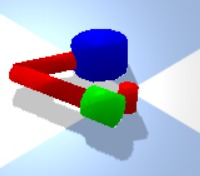
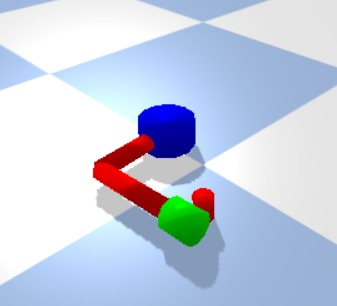
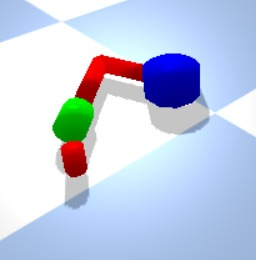